# TP 2 : job d'entraînement, déploiement de modèle, prédiction par batch et en ligne, A/B Testing

### Objectifs

Au cours de ce TP, vous apprendrez à créer un modèle de Vision personnalisé, vous configurerez et lancerez un job d'entraînement, enfin, vous déploierez le modèle pour de la prédiction par lot (batch) puis pour de la prédiction en temps réel (streaming). 

On utilisera le service Azure Machine Leaning suivant : 

## A CHANGER + liens utiles

- Vertex AI Training
- Vertex AI Batch Prediction
- Vertex AI Model resource

Quelques liens utiles :
- [Custom training](https://cloud.google.com/vertex-ai/docs/training/custom-training) 
- [Vertex AI Batch Prediction](https://cloud.google.com/vertex-ai/docs/tabular-data/classification-regression/get-batch-predictions)

### Dataset

TensorFlow met à disposition de nombreux datasets issues de domaines variés et pensés pour le machine learning : [TensorFlow Datasets](https://www.tensorflow.org/datasets/catalog/overview). 

Pour mettre tout ceci en pratique, on utilisera les données [cifar10 dataset](https://www.tensorflow.org/datasets/catalog/cifar10) et on développera un modèle de Computer Vision avec TensorFlow afin de prédire la nature des objets présents sur les images parmi 10 catégories possibles : avion, voiture, oiseau, chat, cerf, chien, grenouille, cheval, bateau, camion.

# Mise en place de l'environnement

### Installer les librairies nécessaires pour intéragir avec Azure ML et autres


In [15]:
!pip install -r requirements.txt

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ---------------------------------------- 5.0/5.0 MB 30.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   ---------------------------------------- 3.0/3.0 MB 44.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   --------------------------------------- 527.0/527.0 kB 16.6 MB/s eta 0:00:00
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21562 sha256=2109133a9396ee37d4058e4c7340187a022bbadd3fb7d20e6b28cc2ac84ac1ac
  Stored in directory: c:\users\ncabourdin\appdata\local\pip\cache\wheels\e1\e8\83\ddea66100678d139b14bc87692ece57c6a2a937956d2532608
Successfully built promise


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorboardx 2.6.1 requires protobuf>=4.22.3, but you have protobuf 4.21.12 which is incompatible.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.13.2 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Variables de connexion à Azure ML

In [90]:
SUBSCRIPTION_ID = "dc0686fc-bdbf-4f78-9f07-ec7bd5755e35" # "à remplir" "_____"
RESOURCE_GROUP = "rg_ncabourdin" # "à remplir"
WORKSPACE_NAME = "mlw-dp100-labs" # "à remplir"

#### Connexion au workspace Azure ML pour utiliser le SDK Python Azure

Le SDK python permet d'utiliser l'API d'Azure avec du code plutôt qu'avec l'interface utilisateur.

In [91]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient(DefaultAzureCredential(), SUBSCRIPTION_ID, RESOURCE_GROUP, WORKSPACE_NAME)

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


### Import des librairies python

# PART 1: Entraînement d'un modèle

Nous allons maintenant créer un modèle de ??? et nous l'entraînerons sur les données MNIST. Ce sont des ???

#### Script d'entrainement

Le script d'entraînement est dans src/tf_mnist.py

### Créer une ressource de calcul

Nous allons maintenant définir un job d'entraînement une ressource de calcul. Azure ML a besoin de cette dernière pour lancer des entraînements.

On provisionne ici un cluster de calcul basé sur Linux. Il y a de nombreuses séries de cluster, utilisant des CPUs, d'autres des GPUs, une certaine quantité de mémoire, de RAM...
Toutes ces caractéristiques ont aussi un rapport avec le prix horaire quand on loue le cluster. [Pricing cluster de calcul](https://azure.microsoft.com/fr-fr/pricing/details/machine-learning/)

## A finir
A CHANGER CAR PAS DE GPU : Nous allons entraîner un modèle de Deep Learning, il nous faut du GPU. On va choisir un cluster possédant du GPU, on va prendre : STANDARD_NC6

On utilise la fonction `AmlCompute` qui prend les paramètres suivant :

ATTENTION : c'est pas un gpu cluster, test avec du cpu

In [28]:
from azure.ai.ml.entities import AmlCompute

gpu_cluster = AmlCompute(
    # Name assigned to the compute cluster
    name="gpu-cluster",
    # Azure ML Compute is the on-demand VM service
    type="amlcompute",
    # VM Family
    size="STANDARD_F72s_v2", 
    # Minimum running nodes when there is no job running
    min_instances=0,
    # Nodes in cluster
    max_instances=4,
    # How many seconds will the node running after the job termination
    idle_time_before_scale_down=180,
    # Dedicated or LowPriority. The latter is cheaper but there is a chance of job termination
    tier="LowPriority",
)

# Now, we pass the object to MLClient's create_or_update method
gpu_cluster = ml_client.begin_create_or_update(gpu_cluster).result()

Veuillez vérifier que le cluster est bien crée en ouvrant le portail Azure ML sur votre navigateur. Il doit avoir 0 noeud de calcul.

## Configure and submit your training job

### Obtain the training data

In [3]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [10]:
import pandas as pd

# Flatten 28x28 images to 784 columns
mnist_df = pd.DataFrame(X_train.reshape(X_train.shape[0], -1))
mnist_df['label'] = y_train

In [18]:
mnist_df

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
59996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
59997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6


In [7]:
mnist_df_test = pd.DataFrame(X_test.reshape(X_test.shape[0], -1))
mnist_df_test

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

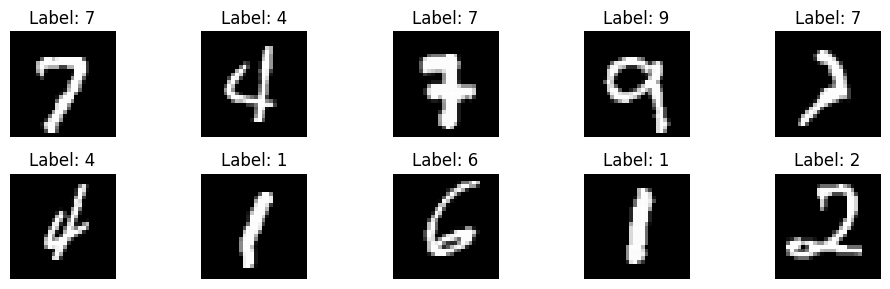

In [65]:
import matplotlib.pyplot as plt

# 2. Sélectionner 10 images aléatoires
indices = np.random.choice(len(X_train), 10, replace=False)
sample_images = X_train[indices]
sample_labels = y_train[indices]

# 3. Visualisation des images (optionnel)
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(sample_images[i], cmap='gray')
    plt.title(f"Label: {sample_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Processing des données pour l'entraînement

Ce script Python permet de convertir des images et leurs étiquettes dans le format IDX, un format binaire couramment utilisé pour les datasets d'entraînement comme MNIST

In [ ]:
import struct
import gzip

# Fonction pour sauvegarder les images au format IDX
def save_images(images, filename):
    with gzip.open(filename, 'wb') as f:
        # Écrire l'en-tête
        magic_number = 2051  # pour les images
        num_images = len(images)
        num_rows = images.shape[1]
        num_cols = images.shape[2]
        
        f.write(struct.pack('>IIII', magic_number, num_images, num_rows, num_cols))
        
        # Écrire les données
        f.write(images.astype(np.uint8).tobytes())

# Fonction pour sauvegarder les étiquettes au format IDX
def save_labels(labels, filename):
    with gzip.open(filename, 'wb') as f:
        # Écrire l'en-tête
        magic_number = 2049  # pour les étiquettes
        num_items = len(labels)
        
        f.write(struct.pack('>II', magic_number, num_items))
        
        # Écrire les données
        f.write(labels.astype(np.uint8).tobytes())

## Sauvegarder les données d'entraînement et de test

Le nom des fichiers est nécessiare ensuite pour le script d'entraînement

In [ ]:
save_images(X_train, "./mnist_gzip/mnist/raw/train-images-idx3-ubyte.gz")
save_labels(y_train, "./mnist_gzip/mnist/raw/train-labels-idx1-ubyte.gz")
save_images(X_test, "./mnist_gzip/mnist/raw/t10k-images-idx3-ubyte.gz")
save_labels(y_test, "./mnist_gzip/mnist/raw/t10k-labels-idx1-ubyte.gz")

## Enregistrer le jeu de données Azure ML

In [87]:
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes

mnist_data = Data(
    path="./mnist_gzip",
    type=AssetTypes.URI_FOLDER,
    name="mnist_gzip_dataset",
    description="MNIST in original gzip format"
)

ml_client.data.create_or_update(mnist_data)

Data({'path': 'azureml://subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourcegroups/rg_ncabourdin/workspaces/mlw-dp100-labs/datastores/workspaceblobstore/paths/LocalUpload/d6a60ecc4cfe45727004ef495966326f/mnist_gzip/', 'skip_validation': False, 'mltable_schema_url': None, 'referenced_uris': None, 'type': 'uri_folder', 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'mnist_gzip_dataset', 'description': 'MNIST in original gzip format', 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourceGroups/rg_ncabourdin/providers/Microsoft.MachineLearningServices/workspaces/mlw-dp100-labs/data/mnist_gzip_dataset/versions/1', 'Resource__source_path': '', 'base_path': 'c:\\Users\\ncabourdin\\projets\\Cours\\Cours ENSTA MLOPS\\mlops-introductory-course-on-microsoft-azure-cloud\\labs\\2_deploy-model_azure', 'creation_context': <azure.ai.ml.entities._system_data.SystemData object at 0x0

Créer un environnement pour le job

In [37]:
curated_env_name = "AzureML-tensorflow-2.12-cuda11@latest"

## Prepare the training script

paramètre à renseigner ?

In [54]:
from azure.ai.ml import command
from azure.ai.ml import Input

job = command(
    inputs=dict(
        data_folder=Input(type="uri_folder", path=mnist_data.path),
        batch_size=64, #"_"
        first_layer_neurons=256,
        second_layer_neurons=128,
        learning_rate=0.01,
    ),
    compute=gpu_cluster.name,
    environment=curated_env_name,
    code="./src/",
    command="python tf_mnist.py --data-folder ${{inputs.data_folder}} --batch-size ${{inputs.batch_size}} --first-layer-neurons ${{inputs.first_layer_neurons}} --second-layer-neurons ${{inputs.second_layer_neurons}} --learning-rate ${{inputs.learning_rate}}",
    experiment_name="tf-dnn-image-classify",
    display_name="tensorflow-classify-mnist-digit-images-with-dnn",
)

Observation des données

## Submit the job

In [55]:
returned_job = ml_client.jobs.create_or_update(job)

What happens during job execution
As the job is executed, it goes through the following stages:

Preparing: A docker image is created according to the environment defined. The image is uploaded to the workspace's container registry and cached for later runs. Logs are also streamed to the job history and can be viewed to monitor progress. If a curated environment is specified, the cached image backing that curated environment will be used.

Scaling: The cluster attempts to scale up if it requires more nodes to execute the run than are currently available.

Running: All scripts in the script folder src are uploaded to the compute target, data stores are mounted or copied, and the script is executed. Outputs from stdout and the ./logs folder are streamed to the job history and can be used to monitor the job.

=> Temps d'entraînement : 9min (sans GPU)

## A VOIR LA PARTIE SUIVANTE

### Tune model parameters

In [23]:
from azure.ai.ml.sweep import Choice, LogUniform

job_for_sweep = job(
    batch_size=Choice(values=[32, 64, 128]),
    first_layer_neurons=Choice(values=[16, 64, 128, 256, 512]),
    second_layer_neurons=Choice(values=[16, 64, 256, 512]),
    learning_rate=LogUniform(min_value=-6, max_value=-1),
)

In [24]:
from azure.ai.ml.sweep import BanditPolicy

sweep_job = job_for_sweep.sweep(
    compute=gpu_cluster.name,
    sampling_algorithm="random",
    primary_metric="validation_acc",
    goal="Maximize",
    max_total_trials=8,
    max_concurrent_trials=4,
    early_termination_policy=BanditPolicy(slack_factor=0.1, evaluation_interval=2),
)

Lancement des entraînements

In [25]:
returned_sweep_job = ml_client.create_or_update(sweep_job)

# refresh the latest status of the job after streaming
returned_sweep_job = ml_client.jobs.get(name=returned_sweep_job.name)

RunId: mighty_net_njhfb6m55j
Web View: https://ml.azure.com/runs/mighty_net_njhfb6m55j?wsid=/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourcegroups/rg_ncabourdin/workspaces/mlw-dp100-labs

Streaming azureml-logs/hyperdrive.txt

[2025-04-17T07:53:47.8508280Z][GENERATOR][DEBUG]Sampled 4 jobs from search space 
[2025-04-17T07:53:48.2789386Z][SCHEDULER][INFO]Scheduling job, id='mighty_net_njhfb6m55j_0' 
[2025-04-17T07:53:48.5084589Z][SCHEDULER][INFO]Scheduling job, id='mighty_net_njhfb6m55j_2' 
[2025-04-17T07:53:48.4064857Z][SCHEDULER][INFO]Scheduling job, id='mighty_net_njhfb6m55j_1' 
[2025-04-17T07:53:48.5091609Z][SCHEDULER][INFO]Scheduling job, id='mighty_net_njhfb6m55j_3' 
[2025-04-17T07:53:48.9079587Z][SCHEDULER][INFO]Successfully scheduled a job. Id='mighty_net_njhfb6m55j_0' 
[2025-04-17T07:53:48.9942434Z][SCHEDULER][INFO]Successfully scheduled a job. Id='mighty_net_njhfb6m55j_2' 
[2025-04-17T07:53:48.8984983Z][SCHEDULER][INFO]Successfully scheduled a job. Id='mighty_net_n

Temps d'exécution : 18 min

## Arrêter le cluster de calcul

Comme le cluster est facturé au temps d'utilisation, pensez à l'éteindre dès qu'il n'est plus nécessaire pour limiter les dépenses.

In [57]:
ml_client.compute.begin_delete(gpu_cluster.name)

## Inscrire dans Azure le modèle entrainé

Choisir le modèle

In [58]:
from azure.ai.ml.entities import Model

# First let us get the run which gave us the best result si sweep job
# run = returned_sweep_job.properties["best_child_run_id"]

# OU seulement le nom du dernier run
run = returned_job.name # meilleur job

# lets get the model from this run
model = Model(
    # the script stores the model as "model"
    path="azureml://jobs/{}/outputs/artifacts/paths/outputs/model/".format(
        run
    ),
    name="run-model-test", #___#
    description="Model created from run.",
    type="custom_model",
)

Inscrire le modèle choisit dans Azure

In [59]:
registered_model = ml_client.models.create_or_update(model=model)

# PART 2 : Déploiement en temps réel

## Inférence en temps réel

Nous allons maintenant utiliser le modèle pour faire de la prédiction en temps réel (batch).

dire object MOE etc..

### Création d'un endpoint

In [112]:
online_endpoint_name = "online-endpoint" # "____"

In [113]:
from azure.ai.ml.entities import (
    ManagedOnlineEndpoint,
    ManagedOnlineDeployment,
    Model
)

# create an online endpoint
endpoint = ManagedOnlineEndpoint(
    name=online_endpoint_name,
    description="Classify handwritten digits using a deep neural network (DNN) using TensorFlow",
    auth_mode="key",
)

endpoint = ml_client.begin_create_or_update(endpoint).result()

print(f"Endpoint {endpoint.name} provisioning state: {endpoint.provisioning_state}")

Endpoint online-endpoint provisioning state: Succeeded


Check the creation, via code ou via le portail Azure ML

In [114]:
endpoint = ml_client.online_endpoints.get(name=online_endpoint_name)

print(
    f'Endpoint "{endpoint.name}" with provisioning state "{endpoint.provisioning_state}" is retrieved'
)

Endpoint "online-endpoint" with provisioning state "Succeeded" is retrieved


#### Déployer le modèle sur l'endpoint

présentation script de scoring

et de chaque argument

In [115]:
model = registered_model

from azure.ai.ml.entities import CodeConfiguration

# create an online deployment.
blue_deployment = ManagedOnlineDeployment(
    name="tff-blue",
    endpoint_name=online_endpoint_name,
    model=model,
    code_configuration=CodeConfiguration(code="./src", scoring_script="score.py"),
    environment=curated_env_name,
    instance_type="Standard_DS3_v2",
    instance_count=1,
)

blue_deployment = ml_client.begin_create_or_update(blue_deployment).result()

Check: endpoint online-endpoint exists


.......................................................................................................................................

Mettre le traffic de l'endpoint à 100%

In [116]:
# Créer une règle de trafic pour le nouveau déploiement
traffic_rules = {
    "tff-blue": 100  # 100% du trafic vers ce déploiement
}

# Mettre à jour l'endpoint avec les nouvelles règles de trafic
endpoint.traffic = traffic_rules
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

Readonly attribute principal_id will be ignored in class <class 'azure.ai.ml._restclient.v2022_05_01.models._models_py3.ManagedServiceIdentity'>
Readonly attribute tenant_id will be ignored in class <class 'azure.ai.ml._restclient.v2022_05_01.models._models_py3.ManagedServiceIdentity'>


ManagedOnlineEndpoint({'public_network_access': 'Enabled', 'provisioning_state': 'Succeeded', 'scoring_uri': 'https://online-endpoint.westeurope.inference.ml.azure.com/score', 'openapi_uri': 'https://online-endpoint.westeurope.inference.ml.azure.com/swagger.json', 'name': 'online-endpoint', 'description': 'Classify handwritten digits using a deep neural network (DNN) using TensorFlow', 'tags': {}, 'properties': {'createdBy': '3c552774-8504-46db-af54-4a996b072734', 'createdAt': '2025-04-22T12:12:36.244809+0000', 'lastModifiedAt': '2025-04-22T13:04:40.954101+0000', 'azureml.onlineendpointid': '/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourcegroups/rg_ncabourdin/providers/microsoft.machinelearningservices/workspaces/mlw-dp100-labs/onlineendpoints/online-endpoint', 'AzureAsyncOperationUri': 'https://management.azure.com/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/providers/Microsoft.MachineLearningServices/locations/westeurope/mfeOperationsStatus/oeidp:ae8a1120-3467-4449

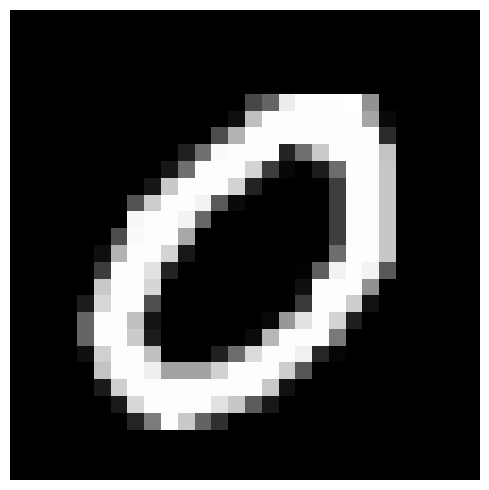

In [121]:
import json
import numpy as np
import matplotlib.pyplot as plt

# 1. Charger le fichier JSON
with open('request\sample-request.json') as f:
    data = json.load(f)

# 2. Extraire les tableaux de pixels
images_data = data['data']  # Liste de tableaux de 784 valeurs

# 3. Convertir en format image (28x28)
images = [np.array(img).reshape(28, 28) for img in images_data]

# 4. Affichage avec matplotlib
plt.figure(figsize=(15, 5))
for i, (img, img_data) in enumerate(zip(images, images_data)):
    plt.subplot(1, len(images), i+1)
    plt.imshow(img, cmap='gray')
    # plt.title(f"Image {i+1}")
    plt.axis('off')
    
    # Optionnel: Afficher les premières valeurs pour vérification
    # print(f"Image {i+1} - 5 premières valeurs: {img_data[:5]}")

plt.tight_layout()
plt.show()

In [96]:
with open('request\sample-request.json') as f:
    data = json.load(f)

# 2. Extraire les tableaux de pixels
images_data = data['data']

In [99]:
images_data[0]

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.27843138575553894,
 0.3960784375667572,
 0.929411768913269,
 0.9960784316

QUESTION : Cout de "Standard_DS3_v2" à l'heure ?

Test déploiement en temps réel

In [119]:
result = ml_client.online_endpoints.invoke(
    endpoint_name=online_endpoint_name,
    request_file="./request/sample-request.json",
    deployment_name="tff-blue",
)

In [120]:
print(result)

[0]


Partie inférence par batch pas encore faite

# Inférence par lot

Nous allons maintenant utiliser le modèle pour faire de la prédiction par lot (batch).

dire object BatchEndp etc..

In [94]:
batch_endpoint_name = "batch-endpoint" # "____"

In [95]:
from azure.ai.ml.entities import BatchEndpoint, BatchDeployment

# Créer un endpoint batch
batch_endpoint = BatchEndpoint(
    name=batch_endpoint_name,
    description="Batch processing of MNIST images"
)
ml_client.begin_create_or_update(batch_endpoint).result()

BatchEndpoint({'scoring_uri': 'https://batch-endpoint.westeurope.inference.ml.azure.com/jobs', 'openapi_uri': None, 'provisioning_state': 'Succeeded', 'name': 'batch-endpoint', 'description': 'Batch processing of MNIST images', 'tags': {}, 'properties': {'BatchEndpointCreationApiVersion': '2023-10-01', 'azureml.onlineendpointid': '/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourceGroups/rg_ncabourdin/providers/Microsoft.MachineLearningServices/workspaces/mlw-dp100-labs/batchEndpoints/batch-endpoint'}, 'print_as_yaml': False, 'id': '/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourceGroups/rg_ncabourdin/providers/Microsoft.MachineLearningServices/workspaces/mlw-dp100-labs/batchEndpoints/batch-endpoint', 'Resource__source_path': '', 'base_path': 'c:\\Users\\ncabourdin\\projets\\Cours\\Cours ENSTA MLOPS\\mlops-introductory-course-on-microsoft-azure-cloud\\labs\\2_deploy-model_azure', 'creation_context': None, 'serialize': <msrest.serialization.Serializer object at 0x000

In [176]:
from azure.ai.ml.entities import AmlCompute

cpu_compute = AmlCompute(
    name="cpu-cluster",
    size="STANDARD_DS3_V2",
    min_instances=0,
    max_instances=2
)
ml_client.compute.begin_create_or_update(cpu_compute)

#### Déployer le modèle sur l'endpoint de batch

Créer l'environnement

In [161]:
from azure.ai.ml.entities import Environment

# Créer un environnement à partir de l'image Docker
env = Environment(
    name="tensorflow-batch-env-test",
    image="mcr.microsoft.com/azureml/curated/tensorflow-2.16-cuda12:11",
    description="Environnement TensorFlow pour le traitement batch"
)
    
# Créer ou mettre à jour l'environnement dans Azure ML
env = ml_client.environments.create_or_update(env)

In [181]:
# Créer une déploiement batch
batch_deployment = BatchDeployment(
    name="deployment-batch",
    endpoint_name=batch_endpoint_name,
    model=model,
    code_configuration=CodeConfiguration(
        code="./src",
        scoring_script="batch_score.py"  # Script spécifique batch
    ),
    environment=env,
    compute=cpu_compute.name,  # Cluster dédié
    instance_count=2
)
ml_client.begin_create_or_update(batch_deployment).result()

Uploading src (0.01 MBs): 100%|##########| 9996/9996 [00:00<00:00, 100646.86it/s]




BatchDeployment({'provisioning_state': 'Succeeded', 'endpoint_name': 'batch-endpoint', 'type': None, 'name': 'deployment-batch', 'description': None, 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourceGroups/rg_ncabourdin/providers/Microsoft.MachineLearningServices/workspaces/mlw-dp100-labs/batchEndpoints/batch-endpoint/deployments/deployment-batch', 'Resource__source_path': '', 'base_path': 'c:\\Users\\ncabourdin\\projets\\Cours\\Cours ENSTA MLOPS\\mlops-introductory-course-on-microsoft-azure-cloud\\labs\\2_deploy-model_azure', 'creation_context': <azure.ai.ml.entities._system_data.SystemData object at 0x000001E9079DCE80>, 'serialize': <msrest.serialization.Serializer object at 0x000001E9095A6FD0>, 'model': '/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourceGroups/rg_ncabourdin/providers/Microsoft.MachineLearningServices/workspaces/mlw-dp100-labs/models/run-model-test/versions/1', 'code_configuration': {'c

Ajouter les données à prédire sur Azure

In [190]:
input_data_asset = Data(
    path="./batch_request/",
    type=AssetTypes.URI_FOLDER,
    name="batch-input-folder-request",
    description="Batch input images",
)
ml_client.data.create_or_update(input_data_asset)

Uploading batch_request (2.44 MBs): 100%|##########| 2435729/2435729 [00:00<00:00, 10870366.55it/s]




Data({'path': 'azureml://subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourcegroups/rg_ncabourdin/workspaces/mlw-dp100-labs/datastores/workspaceblobstore/paths/LocalUpload/e0e1f68a45e4ccd4d72812b7819058d7/batch_request/', 'skip_validation': False, 'mltable_schema_url': None, 'referenced_uris': None, 'type': 'uri_folder', 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'batch-input-folder-request', 'description': 'Batch input images', 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourceGroups/rg_ncabourdin/providers/Microsoft.MachineLearningServices/workspaces/mlw-dp100-labs/data/batch-input-folder-request/versions/1', 'Resource__source_path': '', 'base_path': 'c:\\Users\\ncabourdin\\projets\\Cours\\Cours ENSTA MLOPS\\mlops-introductory-course-on-microsoft-azure-cloud\\labs\\2_deploy-model_azure', 'creation_context': <azure.ai.ml.entities._system_data.SystemData objec

In [192]:
data_asset = ml_client.data.get(name=input_data_asset.name, label="latest")
data_asset

Data({'path': 'azureml://subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourcegroups/rg_ncabourdin/workspaces/mlw-dp100-labs/datastores/workspaceblobstore/paths/LocalUpload/e0e1f68a45e4ccd4d72812b7819058d7/batch_request/', 'skip_validation': False, 'mltable_schema_url': None, 'referenced_uris': None, 'type': 'uri_folder', 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'batch-input-folder-request', 'description': 'Batch input images', 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/dc0686fc-bdbf-4f78-9f07-ec7bd5755e35/resourceGroups/rg_ncabourdin/providers/Microsoft.MachineLearningServices/workspaces/mlw-dp100-labs/data/batch-input-folder-request/versions/1', 'Resource__source_path': '', 'base_path': 'c:\\Users\\ncabourdin\\projets\\Cours\\Cours ENSTA MLOPS\\mlops-introductory-course-on-microsoft-azure-cloud\\labs\\2_deploy-model_azure', 'creation_context': <azure.ai.ml.entities._system_data.SystemData objec

In [193]:
input_data_batch = Input(path=data_asset.id)

Test déploiement par lot

In [195]:
# Créer un job batch
result_batch = ml_client.batch_endpoints.invoke(
    endpoint_name=batch_endpoint_name,
    deployment_name=batch_deployment.name,
    inputs={"data":input_data_batch}
)

In [196]:
ml_client.jobs.get(result_batch.name)

Experiment,Name,Type,Status,Details Page
batch-endpoint,batchjob-0dc696dd-be63-4fc9-9583-352dd7644c42,pipeline,Completed,Link to Azure Machine Learning studio


In [197]:
ml_client.jobs.download(name=result_batch.name, download_path=".", output_name="score")

### Evaluer les résulats

On pourra essayer d'autres paramètres d'entrainement pour augmenter les performances du modèle.

In [242]:
import json
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def load_json_file(file_path):
    """Load labels from a JSON file"""
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data["labels"]

def load_predictions(file_path):
    """Load predictions from CSV file"""
    predictions = []
    with open(file_path, 'r') as f:
        for line in f:
            list_line=[int(x) for x in line if x.isdigit()]
            predictions.extend(list_line)
        print(len(predictions))
    return predictions

def evaluate(y_true, y_pred):
    """Evaluate predictions against true labels"""
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    
    # Print classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    # Print confusion matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

In [243]:
true_labels_paths = ["batch_request_result\mnist_labels_batch_1.json", "batch_request_result\mnist_labels_batch_2.json", "batch_request_result\mnist_labels_batch_3.json",
"batch_request_result\mnist_labels_batch_4.json", "batch_request_result\mnist_labels_batch_5.json"]  # "_____"
predictions_path = "predictions.csv"  # Adjust filename

# Load true labels
true_labels = []
for path in true_labels_paths:
    true_labels.extend(load_json_file(path))

# Load predictions
predictions = load_predictions(predictions_path)

# Evaluate
print(f"Evaluating {len(true_labels)} samples...")
evaluate(true_labels, predictions)

150
Evaluating 150 samples...
Accuracy: 0.9667
Classification Report:
              precision    recall  f1-score   support

           0     0.9500    1.0000    0.9744        19
           1     0.8571    0.9231    0.8889        13
           2     1.0000    0.9545    0.9767        22
           3     1.0000    1.0000    1.0000        12
           4     1.0000    1.0000    1.0000        15
           5     1.0000    1.0000    1.0000         9
           6     0.9000    0.9000    0.9000        10
           7     1.0000    1.0000    1.0000        21
           8     0.9333    1.0000    0.9655        14
           9     1.0000    0.8667    0.9286        15

    accuracy                         0.9667       150
   macro avg     0.9640    0.9644    0.9634       150
weighted avg     0.9684    0.9667    0.9667       150

Confusion Matrix:
[[19  0  0  0  0  0  0  0  0  0]
 [ 0 12  0  0  0  0  0  0  1  0]
 [ 1  0 21  0  0  0  0  0  0  0]
 [ 0  0  0 12  0  0  0  0  0  0]
 [ 0  0  0  0 15  0  

Arrêt de l'endpoint en temps réel

In [124]:
ml_client.online_endpoints.begin_delete(
    name=online_endpoint_name,
)

...............................................................................................................................................................................................................................................................

Arrêt du cluster et de l'endpoint par batch

In [ ]:
ml_client.compute.begin_delete(cpu_compute.name)

In [ ]:
ml_client.online_endpoints.begin_delete(
    name=batch_endpoint_name,
    purge=True
)

# Partie 4 : Test de charge

### A MODIFIER Déployer le modèle sur un endpoint

Avant de pouvoir obtenir des prédictions, le modèle doit être déployé sur un `Endpoint`. L'endpoint est un serveur qui tourne sur les ressources qu'on définit au préalable. Il gère les requêtes qu'il reçoit au format HTTP et distribue les calculs pour une réponse avec un minimum de latence.

On utilisera la fonction `deploy` qui prend en entrée :

- `deployed_model_display_name`: Un nom pour le modèle deployé
- `traffic_split`: Le pourcentage du trafic de l'endpoint qui va être transmis aux différents modèles de l'edpoint.
   - On précisera la répartition du trafic sous forme de dictionnaire python où les clés sont les id des modèles et les valeurs sont les pourcentages de trafic qui doivent sommer à 100. On utilise "0" pour la clé du modèle que l'on déploie. Ex : *{ "0": percent, model_id: percent, ... }**
- `machine_type`: Le type de machine pour l'entraînement.
- `accelerator_type`: Le type d'accelerateur (GPU, TPU).
- `accelerator_count`: Le nombre d'accelerateur par worker.
- `starting_replica_count`: Le nombre initial d'instance de calcul.
- `min_replica_count`: Le nombre minimum d'instances de calcul que Vertex AI doit attribuer à l'endpoint.
- `max_replica_count`: Le nombre maximum d'instances de calcul que Vertex AI puisse attribuer à l'endpoint pour l'_autoscaling_.

### Traffic split

Le `traffic_split` est généralement utilisé pour introduire graduellement un nouveau modèle en production. C'est ce qu'on appelle l'A/B testing, et cela permet de comparer les performances d'un nouveau modèle en production tout en minimizant le risque d'un changement brutal pour la plupart des utilisateurs.

In [13]:
DEPLOYED_NAME = "cifar10_deployed_unique"

TRAFFIC_SPLIT = {"0": 100}

MIN_NODES = 1
MAX_NODES = 1

#model = aiplatform.Model('3904388879976759296')

endpoint = model.deploy(
    deployed_model_display_name=DEPLOYED_NAME,
    machine_type='n1-highcpu-4',
    traffic_split=TRAFFIC_SPLIT,
    min_replica_count=MIN_NODES,
    max_replica_count=4,
)

Creating Endpoint
Create Endpoint backing LRO: projects/837843744498/locations/us-central1/endpoints/3863531027888603136/operations/8263665614652964864
Endpoint created. Resource name: projects/837843744498/locations/us-central1/endpoints/3863531027888603136
To use this Endpoint in another session:
endpoint = aiplatform.Endpoint('projects/837843744498/locations/us-central1/endpoints/3863531027888603136')
Deploying model to Endpoint : projects/837843744498/locations/us-central1/endpoints/3863531027888603136
Deploy Endpoint model backing LRO: projects/837843744498/locations/us-central1/endpoints/3863531027888603136/operations/5904623834840956928
Endpoint model deployed. Resource name: projects/837843744498/locations/us-central1/endpoints/3863531027888603136


#### Préparer les images

Les images qui seront envoyés à l'endpoint doivent être _préprocessées_ afin qu'elles soient au même format que le format d'entrée du script d'entraînement `task.py`.

Préparer un batch d'image a envoyer a l'endpoint afin d'obtenir les meme résultats que lors de l'inférence précédente

In [27]:
import os
import numpy as np
from PIL import Image

# Load image data
IMAGE_DIRECTORY = "cifar_test_images"

image_files = ... # list of paths

# Decode JPEG images into numpy arrays
image_data = ...

# Scale and convert to expected format
x_test = ...

# Extract labels from image name
y_test = ...

In [36]:
len(x_test)

10

### Envoyer les requêtes de prédiction

On utilise la méthode `predict` de l'objet `Endpoint`. La fonction retourne une liste où chaque élément correspond à une image de la requête. 

Dans la cellule suivante, on lance une évaluation des résultats de prédiction comme pour la prédiction par bacth, on ne devrait pas observer de changement de performance.

In [35]:
# A priori, l'endpoint est déja chargé à ce stade. Sinon :
# endpoint = aiplatform.Endpoint(ENDPOINT_ID)

predictions = endpoint.predict(instances=x_test)

Correct predictions = 2, Total predictions = 10, Accuracy = 0.2


In [ ]:
# Implementer une évaluation des résultats

# Part 5 : Montée en charge de l'endpoint 

Dans cette partie nous allons tester la capacité de notre endpoint a pouvoir monter en charge. Dans un cas d'usage où nous constuisons une application ayant comme vocation a recevoir beacuoup de connexion, 
nous devons nous assurer que les modèles ont cette capacité a traiter ce traffic. 

Ainsi, nous allons utiliser la librairie Locust, elle permet de réaliser des test de charge sur des API. 

Le code api.py contient déjà tous les élément permettant de construire une API qui héberge notre endpoint. 

- Il vous faut dans un premier temps remplacer les variables PROJECT_ID, LOCATION, BUCKET_URI, ID_ENDPOINT par les variables que vous avez utilisé précédemment

- Pour déployé l'API en local, veuillez lancer la commande suivante $python -m unicorn api:app --reload --port 8080 (veuillez vérifier en amont que vous possédez bien les librairie FastAPi et uvicorn)

- Ensuite, ouvrez le script locust.py vérifiez bien que la fonction load_data() fonctionne dans votre cas. et adapter le script pour que l'appel ne comportant qu'une seule image. 


- Lancer l'application locust avec la commande $locust -f locustfile.py (!! librairie nécessaire locust, PyYAML, flask !!) 

Réalisez plusieurs test de votre endpoint 

Ex: 

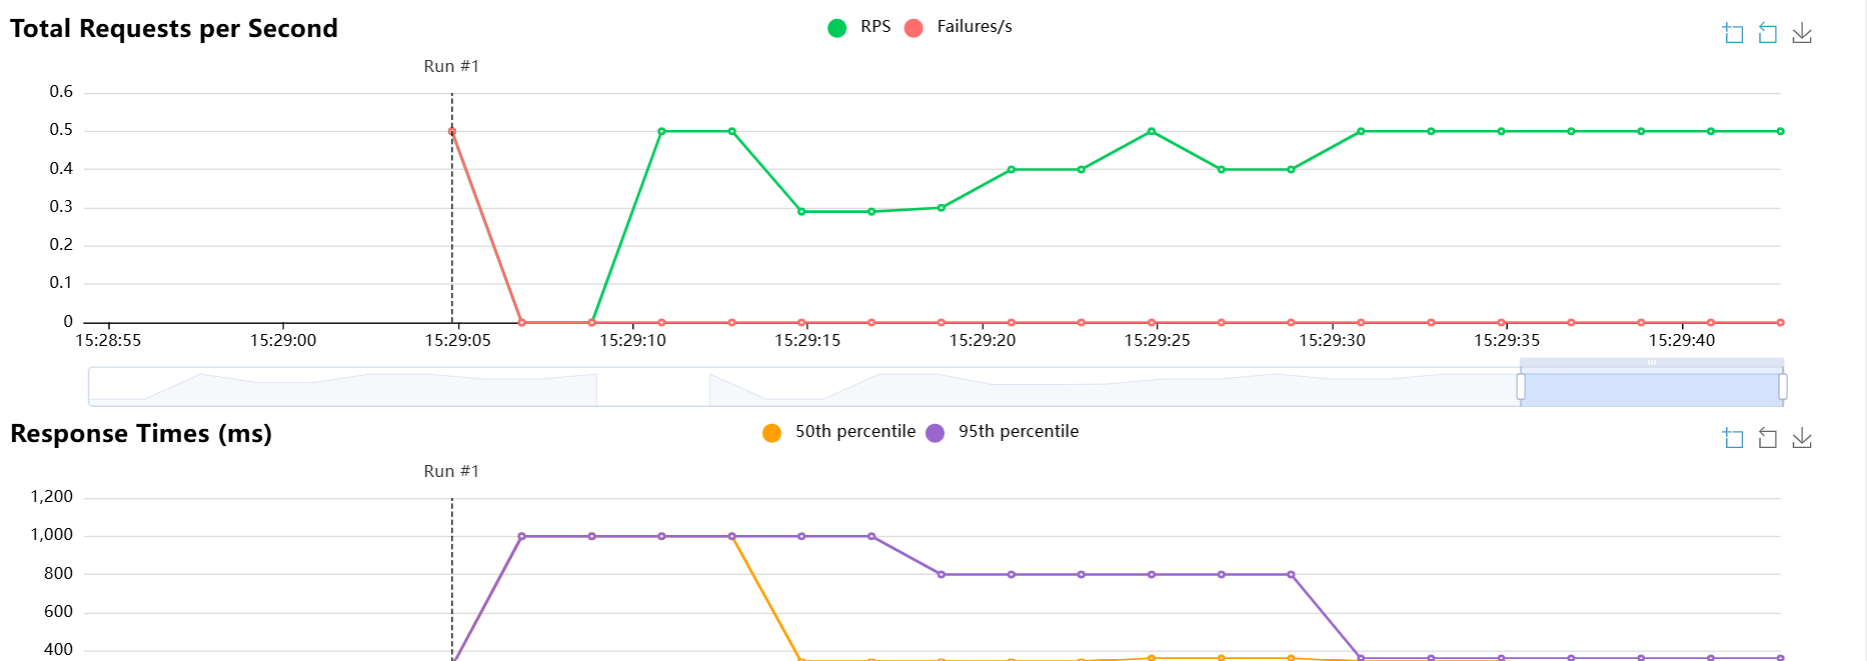

Q2 : Quels sont les limites de l'endpoint ? Avez vous pu observer la scalabilité automatique de vertexAI ? (Argumentez avec des graphs)

Q3 : Est ce que les limitations observé sont uniquement du au endpoint vertexAI ?

Q4 : Mise en situation, j'ai développé une application mobile pour une grande marque de vétements, qui permet de prendre une photo d'un habits et de retrouver un article similaire dans leur shop. Le modèle utilisé est similaire a celui de notre exemple. Nous avons déployé ce modèle sur un endpoint VertexAI. L'application a été téléchargé plus de 50 000 fois, on estime qu'un utilisateur fais une recherche par jour. Pouvez vous dire si cette méthode de déploiement est viable pour notre application ? (Ouvert)

# Nettoyage du projet

In [69]:
# Delete the training job
job.delete()

# Delete the model
model.delete()

Deleting CustomTrainingJob : projects/837843744498/locations/us-central1/trainingPipelines/5233020004923867136


NotFound: 404 Job "projects/837843744498/locations/us-central1/trainingPipelines/5233020004923867136" does not exist.

A SUPPRIMER

In [189]:
indices = np.random.choice(len(X_test), 150, replace=False)
selected_images = X_test[indices]
selected_labels = y_test[indices] 

# 3. Normaliser et flatten les images
processed_images = (selected_images / 255.0).reshape(150, 784)

# 4. Créer 5 fichiers JSON avec 30 images chacun
for i in range(5):
    # Extraire 30 images
    start_idx = i * 30
    end_idx = (i + 1) * 30
    images_group = processed_images[start_idx:end_idx].tolist()
    labels_group = selected_labels[start_idx:end_idx].tolist()
    
    # Créer la structure JSON
    json_data = {"data": images_group}
    
    # Sauvegarder dans un fichier
    filename = f"mnist_batch_{i+1}.json"
    with open(filename, 'w') as f:
        json.dump(json_data, f, indent=4)

    # Sauvegarder les labels dans un autre fichier
    label_json = {"labels": labels_group}
    label_filename = f"mnist_labels_batch_{i+1}.json"
    with open(label_filename, 'w') as f:
        json.dump(label_json, f, indent=4)